<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Fraud-Detection-with-Federated-Learning/blob/main/Credit_Card_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#For credit card i change the batch size 512(Small dataset) and added seed , then csv files codes also added

In [23]:
# ================================================
# Credit Card Fraud Detection using DNNs
# (No FL, FedAvg, FedBN) - FINAL VERSION
# ================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gc

# -----------------------------
# 0. SET SEED (IMPORTANT)
# -----------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# -----------------------------
# 1. Load dataset
# -----------------------------

os.environ['KAGGLE_USERNAME'] = "devindithathsara "
os.environ['KAGGLE_KEY'] = "29219555"

print(" Downloading dataset from Kaggle...")
!pip install -q kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip -d dataset/

import pandas as pd
from sklearn.preprocessing import StandardScaler

print(" Loading and preprocessing dataset...")
df = pd.read_csv('dataset/creditcard.csv')  # replace with your path
print("Dataset shape:", df.shape)




# -----------------------------
# 2. PREPROCESSING
# -----------------------------
X = df.drop("Class", axis=1).values
y = df["Class"].values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

INPUT_DIM = X.shape[1]

# -----------------------------
# 3. TRAIN-TEST SPLIT
# -----------------------------
TEST_SIZE = 0.2
NUM_CLIENTS = 12
alpha = 0.5

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# -----------------------------
# 4. DIRICHLET SPLIT
# -----------------------------
def dirichlet_split(X, y, num_clients, alpha):
    np.random.seed(SEED)
    data_per_client = [[] for _ in range(num_clients)]
    labels = np.unique(y)

    for label in labels:
        idx = np.where(y == label)[0]
        np.random.shuffle(idx)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        split_idx = np.split(idx, proportions)

        for i in range(num_clients):
            data_per_client[i].extend(split_idx[i])

    clients_data = {}
    for i in range(num_clients):
        client_idx = data_per_client[i]
        clients_data[i] = {"X": X[client_idx], "y": y[client_idx]}

    return clients_data

raw_clients_train = dirichlet_split(X_train_full, y_train_full, NUM_CLIENTS, alpha)

# -----------------------------
# 5. PREPARE CLIENT DATA
# -----------------------------
clients_train_data = {}
clients_test_data = {}

for i in range(NUM_CLIENTS):
    clients_train_data[i] = {
        "X": raw_clients_train[i]["X"].astype("float32"),
        "y": raw_clients_train[i]["y"].astype("float32")
    }

    clients_test_data[i] = {
        "X": X_test_full.astype("float32"),
        "y": y_test_full.astype("float32")
    }

# -----------------------------
# 6. MODEL
# -----------------------------
def create_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# HYPERPARAMETERS
# -----------------------------
LOCAL_EPOCHS = 5
BATCH_SIZE = 512
NUM_ROUNDS = 20

# -----------------------------
# 7. NO FEDERATED LEARNING
# -----------------------------
print("\n=== NO FEDERATED LEARNING ===")

client_models_noFL = []
local_accs = []

for cid in range(NUM_CLIENTS):
    print(f"\nClient {cid+1}")
    model = create_model()

    model.fit(
        clients_train_data[cid]["X"],
        clients_train_data[cid]["y"],
        epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    loss, acc = model.evaluate(
        clients_test_data[cid]["X"],
        clients_test_data[cid]["y"],
        verbose=0
    )

    local_accs.append(acc)
    client_models_noFL.append(model)
    print(f"Accuracy: {acc:.4f}")

# Save CSV
df_noFL = pd.DataFrame({
    "Client": list(range(1, NUM_CLIENTS+1)),
    "Accuracy": local_accs
})
df_noFL.to_csv("credit_noFL.csv", index=False)

# -----------------------------
# 8. FEDAVG
# -----------------------------
print("\n=== FEDAVG ===")

global_model_fedavg = create_model()
round_accs_fedavg = []
round_losses_fedavg = []   # ADDED

def fedavg_aggregate(client_weights):
    return [np.mean(w, axis=0) for w in zip(*client_weights)]

for r in range(NUM_ROUNDS):
    print(f"Round {r+1}")

    client_weights = []

    for cid in range(NUM_CLIENTS):
        local_model = create_model()
        local_model.set_weights(global_model_fedavg.get_weights())

        local_model.fit(
            clients_train_data[cid]["X"],
            clients_train_data[cid]["y"],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        client_weights.append(local_model.get_weights())

    global_model_fedavg.set_weights(fedavg_aggregate(client_weights))

    accs = []
    losses = []   # ADDED
    for cid in range(NUM_CLIENTS):
        loss, acc = global_model_fedavg.evaluate(
            clients_test_data[cid]["X"],
            clients_test_data[cid]["y"],
            verbose=0
        )
        accs.append(acc)
        losses.append(loss)   # ADDED

    avg_acc = np.mean(accs)
    avg_loss = np.mean(losses) # ADDED
    round_accs_fedavg.append(avg_acc)
    round_losses_fedavg.append(avg_loss) # ADDED
    print(f"Avg Accuracy: {avg_acc:.4f} | Avg Loss: {avg_loss:.4f}") # MODIFIED PRINT

    gc.collect()

# Save CSV
pd.DataFrame({
    "Round": list(range(1, NUM_ROUNDS+1)),
    "Accuracy": round_accs_fedavg,
    "Loss": round_losses_fedavg # ADDED
}).to_csv("credit_fedavg.csv", index=False)

# -----------------------------
# 9. FEDBN
# -----------------------------
print("\n=== FEDBN ===")

global_model_fedbn = create_model()
client_models_fedbn = [create_model() for _ in range(NUM_CLIENTS)]

for m in client_models_fedbn:
    m.set_weights(global_model_fedbn.get_weights())

round_accs_fedbn = []
round_losses_fedbn = []   # ADDED

def sync_non_bn(global_model, local_model):
    for g, l in zip(global_model.layers, local_model.layers):
        if "batch_normalization" not in g.name.lower():
            l.set_weights(g.get_weights())

def fedbn_aggregate(client_models, global_model):
    new_weights = []

    for i, layer in enumerate(global_model.layers):
        if "batch_normalization" not in layer.name.lower():
            weights = [m.layers[i].get_weights() for m in client_models]
            avg = [np.mean(w, axis=0) for w in zip(*weights)]
            new_weights.extend(avg)
        else:
            new_weights.extend(layer.get_weights())

    return new_weights

for r in range(NUM_ROUNDS):
    print(f"Round {r+1}")

    for cid in range(NUM_CLIENTS):
        local_model = client_models_fedbn[cid]
        sync_non_bn(global_model_fedbn, local_model)

        local_model.fit(
            clients_train_data[cid]["X"],
            clients_train_data[cid]["y"],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

    global_model_fedbn.set_weights(
        fedbn_aggregate(client_models_fedbn, global_model_fedbn)
    )

    accs = []
    losses = []   # ADDED
    for cid in range(NUM_CLIENTS):
        loss, acc = client_models_fedbn[cid].evaluate(
            clients_test_data[cid]["X"],
            clients_test_data[cid]["y"],
            verbose=0
        )
        accs.append(acc)
        losses.append(loss)   # ADDED

    avg_acc = np.mean(accs)
    avg_loss = np.mean(losses) # ADDED
    round_accs_fedbn.append(avg_acc)
    round_losses_fedbn.append(avg_loss) # ADDED
    print(f"Avg Accuracy: {avg_acc:.4f} | Avg Loss: {avg_loss:.4f}") # MODIFIED PRINT

    gc.collect()

# Save CSV
pd.DataFrame({
    "Round": list(range(1, NUM_ROUNDS+1)),
    "Accuracy": round_accs_fedbn,
    "Loss": round_losses_fedbn # ADDED
}).to_csv("credit_fedbn.csv", index=False)

print("\n DONE - CSV files saved!")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  creditcardfraud.zip
  inflating: dataset/creditcard.csv  
 Loading and preprocessing dataset...
Dataset shape: (284807, 31)

=== NO FEDERATED LEARNING ===

Client 1
Accuracy: 0.9958

Client 2
Accuracy: 0.5397

Client 3
Accuracy: 0.8738

Client 4
Accuracy: 0.9994

Client 5
Accuracy: 0.9618

Client 6
Accuracy: 0.9982

Client 7
Accuracy: 0.9985

Client 8
Accuracy: 0.9992

Client 9
Accuracy: 0.8790

Client 10
Accuracy: 0.9984

Client 11
Accuracy: 0.6278

Client 12
Accuracy: 0.8749

=== FEDAVG ===
Round 1
Avg Accuracy: 0.9983 | Avg Loss: 0.2559
Round 2
Avg Accuracy: 0.9992 | Avg Loss: 0.0574
Round 3
Avg Accuracy: 0.9992 | Avg Loss: 0.0116
Round 4
Avg Accuracy: 0.9992 | Avg Loss: 0.0041
Round 5
Avg Accuracy: 0.9993 | Avg Loss: 0.0032
Round 6
Avg Accuracy: 0.9993 | Avg Loss: 0.0031
Round 7
Avg

#Visualization Part

ACCURACY COMPARISON GRAPH

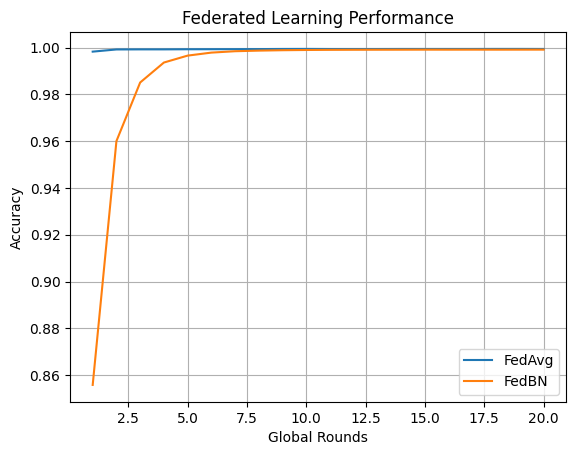

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

fedavg = pd.read_csv("credit_fedavg.csv")
fedbn = pd.read_csv("credit_fedbn.csv")

plt.figure()
plt.plot(fedavg["Round"], fedavg["Accuracy"], label="FedAvg")
plt.plot(fedbn["Round"], fedbn["Accuracy"], label="FedBN")

plt.xlabel("Global Rounds")
plt.ylabel("Accuracy")
plt.title("Federated Learning Performance")
plt.legend()
plt.grid()

plt.savefig("accuracy_comparison.png")
plt.show()

Client Comparison

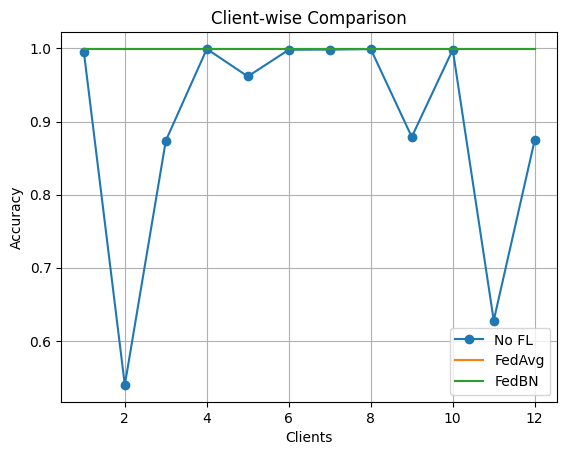

In [25]:
no_fl = pd.read_csv("credit_noFL.csv")

clients = no_fl["Client"]

plt.figure()
plt.plot(clients, no_fl["Accuracy"], marker='o', label="No FL")

# Final values from FL
fedavg_final = fedavg["Accuracy"].iloc[-1]
fedbn_final = fedbn["Accuracy"].iloc[-1]

plt.plot(clients, [fedavg_final]*len(clients), label="FedAvg")
plt.plot(clients, [fedbn_final]*len(clients), label="FedBN")

plt.xlabel("Clients")
plt.ylabel("Accuracy")
plt.title("Client-wise Comparison")
plt.legend()
plt.grid()

plt.savefig("client_comparison.png")
plt.show()

#Heat Map

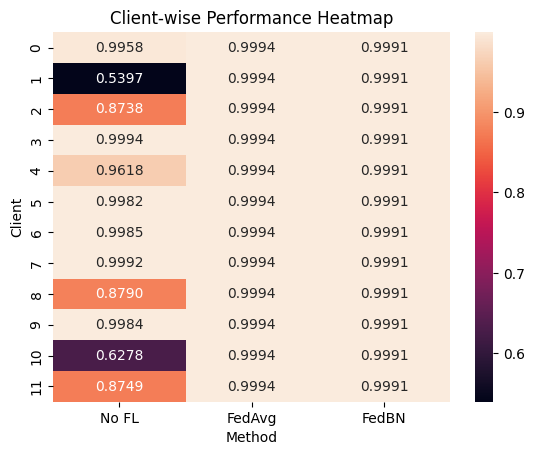

In [26]:
import seaborn as sns

data = []

for i in range(len(no_fl)):
    data.append([
        no_fl["Accuracy"][i],
        fedavg_final,
        fedbn_final
    ])

df_heat = pd.DataFrame(data, columns=["No FL", "FedAvg", "FedBN"])

plt.figure()
sns.heatmap(df_heat, annot=True, fmt=".4f")

plt.title("Client-wise Performance Heatmap")
plt.xlabel("Method")
plt.ylabel("Client")

plt.savefig("heatmap.png")
plt.show()

Client accuracy Live Demo

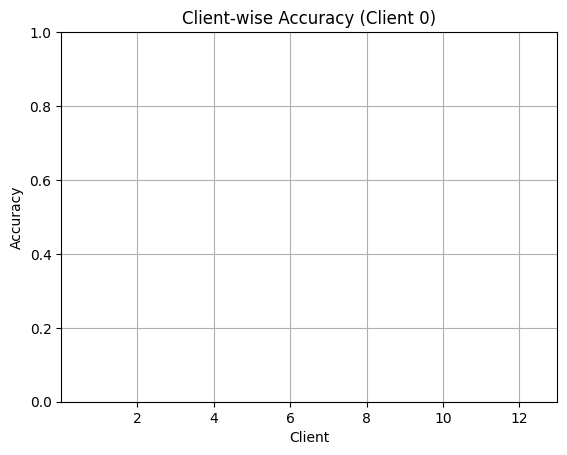

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

df = pd.read_csv("credit_noFL.csv")

fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    ax.bar(df["Client"][:frame], df["Accuracy"][:frame])
    ax.set_title(f"Client-wise Accuracy (Client {frame})")
    ax.set_xlabel("Client")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.grid()

ani = FuncAnimation(fig, update, frames=len(df)+1, interval=600)

HTML(ani.to_jshtml())

FedAvg vs FedBN comparison

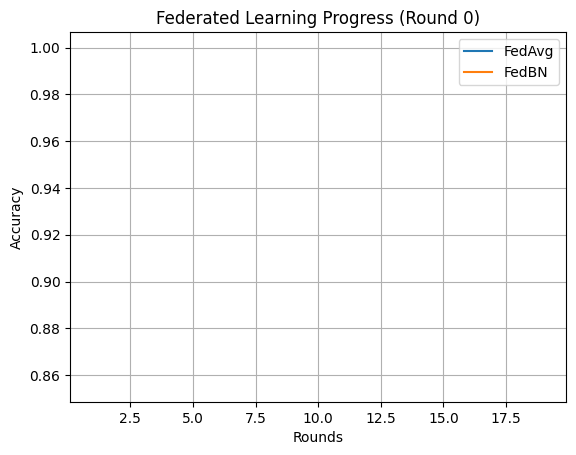

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Load CSVs
fedavg = pd.read_csv("credit_fedavg.csv")
fedbn = pd.read_csv("credit_fedbn.csv")

fig, ax = plt.subplots()

def update(frame):
    ax.clear()

    ax.plot(fedavg["Round"][:frame], fedavg["Accuracy"][:frame], label="FedAvg")
    ax.plot(fedbn["Round"][:frame], fedbn["Accuracy"][:frame], label="FedBN")

    ax.set_title(f"Federated Learning Progress (Round {frame})")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid()

ani = FuncAnimation(fig, update, frames=len(fedavg), interval=500)

#  IMPORTANT LINE
HTML(ani.to_jshtml())

Confusion Matrix

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


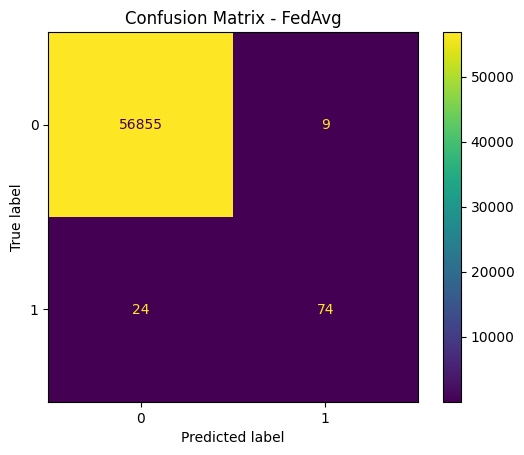

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (global_model_fedavg.predict(X_test_full) > 0.5).astype(int)

cm = confusion_matrix(y_test_full, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - FedAvg")
plt.show()

In [13]:
streamlit run app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Fraud Detection Dashboard")

fedavg = pd.read_csv("credit_fedavg.csv")
fedbn = pd.read_csv("credit_fedbn.csv")

option = st.selectbox("Select View", ["Accuracy Graph", "Comparison"])

if option == "Accuracy Graph":
    fig, ax = plt.subplots()
    ax.plot(fedavg["Round"], fedavg["Accuracy"], label="FedAvg")
    ax.plot(fedbn["Round"], fedbn["Accuracy"], label="FedBN")
    ax.legend()
    ax.set_title("Accuracy vs Rounds")
    st.pyplot(fig)

if option == "Comparison":
    st.write("FedAvg Final:", fedavg["Accuracy"].iloc[-1])
    st.write("FedBN Final:", fedbn["Accuracy"].iloc[-1])

SyntaxError: invalid syntax (2279280421.py, line 1)

In [30]:
round_accs_fedavg = []
round_losses_fedavg = []   # ✅ ADD THIS

In [31]:
accs = []
losses = []   # ✅ ADD

for cid in range(NUM_CLIENTS):
    loss, acc = global_model_fedavg.evaluate(
        clients_test_data[cid]["X"],
        clients_test_data[cid]["y"],
        verbose=0
    )
    accs.append(acc)
    losses.append(loss)   # ✅ ADD

avg_acc = np.mean(accs)
avg_loss = np.mean(losses)   # ✅ ADD

round_accs_fedavg.append(avg_acc)
round_losses_fedavg.append(avg_loss)   # ✅ ADD

print(f"Round {r+1} | Acc: {avg_acc:.4f} | Loss: {avg_loss:.4f}")

Round 20 | Acc: 0.9994 | Loss: 0.0039


ValueError: All arrays must be of the same length

In [ ]:
round_accs_fedbn = []
round_losses_fedbn = []   # ✅ ADD

In [ ]:
accs = []
losses = []   # ✅ ADD

for cid in range(NUM_CLIENTS):
    loss, acc = client_models_fedbn[cid].evaluate(
        clients_test_data[cid]["X"],
        clients_test_data[cid]["y"],
        verbose=0
    )
    accs.append(acc)
    losses.append(loss)   # ✅ ADD

avg_acc = np.mean(accs)
avg_loss = np.mean(losses)   # ✅ ADD

round_accs_fedbn.append(avg_acc)
round_losses_fedbn.append(avg_loss)   # ✅ ADD

print(f"Round {r+1} | Acc: {avg_acc:.4f} | Loss: {avg_loss:.4f}")

In [ ]:
pd.DataFrame({
    "Round": list(range(1, NUM_ROUNDS+1)),
    "Accuracy": round_accs_fedbn,
    "Loss": round_losses_fedbn
}).to_csv("credit_fedbn.csv", index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fedavg = pd.read_csv("credit_fedavg.csv")
fedbn = pd.read_csv("credit_fedbn.csv")

plt.figure()
plt.plot(fedavg["Round"], fedavg["Loss"], label="FedAvg Loss")
plt.plot(fedbn["Round"], fedbn["Loss"], label="FedBN Loss")

plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.title("Loss vs Federated Rounds")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    ax.plot(fedavg["Round"][:frame], fedavg["Loss"][:frame], label="FedAvg")
    ax.plot(fedbn["Round"][:frame], fedbn["Loss"][:frame], label="FedBN")

    ax.set_title(f"Loss Reduction (Round {frame})")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid()

ani = FuncAnimation(fig, update, frames=len(fedavg), interval=500)

HTML(ani.to_jshtml())